In [1]:
pip install fcmpy matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


# Simulation FCM : Marketing impact on sales

## Model Concepts
1. **Advertising**: Budget allocated to campaigns.
2. **Awareness**: Brand visibility among customers.
3. **Sales**: Revenue generated.

## Causal Relationships
- Advertising increases Awareness.
- Advertising has a direct effect on Sales.
- Awareness increases Sales.
- Sales generate word-of-mouth, increasing Awareness (Positive feedback).

In [1]:
from fcmpy import FcmSimulator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

weight_matrix = pd.DataFrame(np.array([
    [0,    0.8,  0.4],  
    [0,    0,    0.9],  
    [0,    0.5,  0]    
]), 
columns=['Advertising', 'Awareness', 'sales'])

print("Causal weight matrix :")
weight_matrix

Causal weight matrix :


,Advertising,Awareness,sales
0,0.0,0.8,0.4
1,0.0,0.0,0.9
2,0.0,0.5,0.0


In [2]:
init_state = {
    'Advertising': 0.5, 
    'Awareness': 0.3, 
    'sales': 0.4
}

sim = FcmSimulator()

print("Initial state defined :", init_state)

Initial state defined : {'Advertising': 0.5, 'Awareness': 0.3, 'sales': 0.4}


The values converged in the 7 state (e <= 0.001)
The values converged in the 6 state (e <= 0.001)


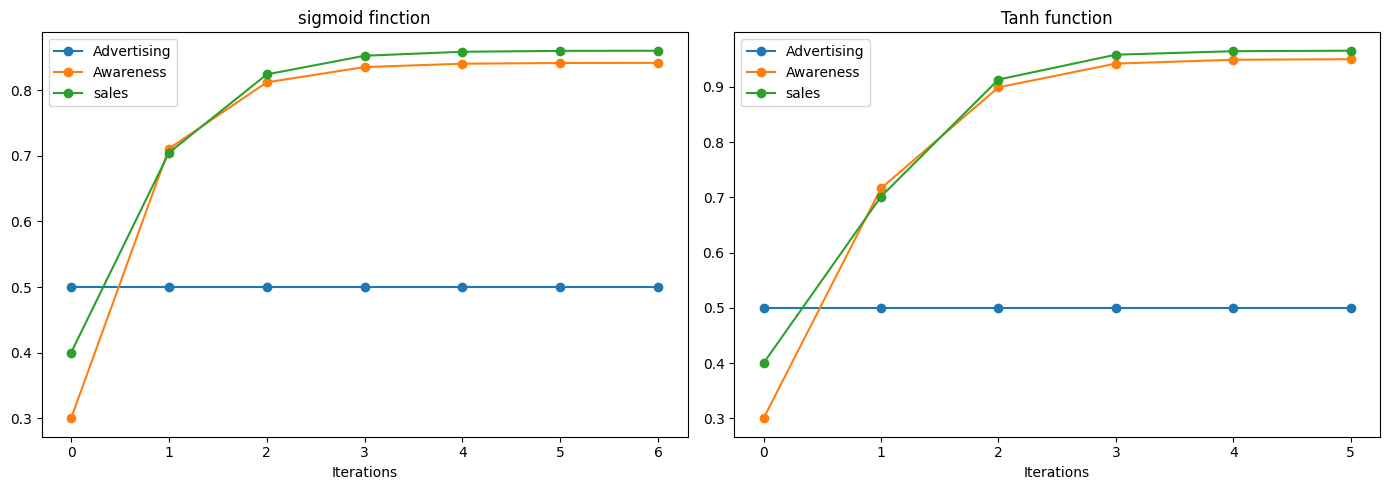

In [3]:
res_sigmoid = sim.simulate(
    initial_state=init_state, 
    weight_matrix=weight_matrix, 
    transfer='sigmoid', 
    inference='mKosko', 
    thresh=0.001, 
    iterations=50, 
    l=1
)

res_hyperbolic = sim.simulate(
    initial_state=init_state, 
    weight_matrix=weight_matrix, 
    transfer='tanh', 
    inference='mKosko', 
    thresh=0.001, 
    iterations=50, 
    l=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_sigmoid.plot(ax=axes[0], marker='o')
axes[0].set_xlabel("Iterations")
axes[0].set_title("sigmoid finction")
axes[0].legend(['Advertising', 'Awareness', 'sales'])

# Graph TanH
res_hyperbolic.plot(ax=axes[1], marker='o')
axes[1].set_xlabel("Iterations")
axes[1].set_title("Tanh function")
axes[1].legend(['Advertising', 'Awareness', 'sales'])

plt.tight_layout()
plt.show()

In [5]:
from fcmpy import FcmIntervention

inter = FcmIntervention(FcmSimulator)

inter.initialize(
    initial_state=init_state, 
    weight_matrix=weight_matrix,
    transfer="tanh", 
    inference="mKosko",
    thresh=0.001, 
    iterations=50, 
    l=1
)

baseline = inter.test_results["baseline"]

inter.add_intervention(
    "Advertising_Boost", 
    type="continuous", 
    impact={"Advertising": 0.4}, 
    effectiveness=1
)

inter.test_intervention("Advertising_Boost", iterations=50)

intervention_result = inter.test_results["Advertising_Boost"][['Advertising', 'Awareness', 'sales']]

The values converged in the 6 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)


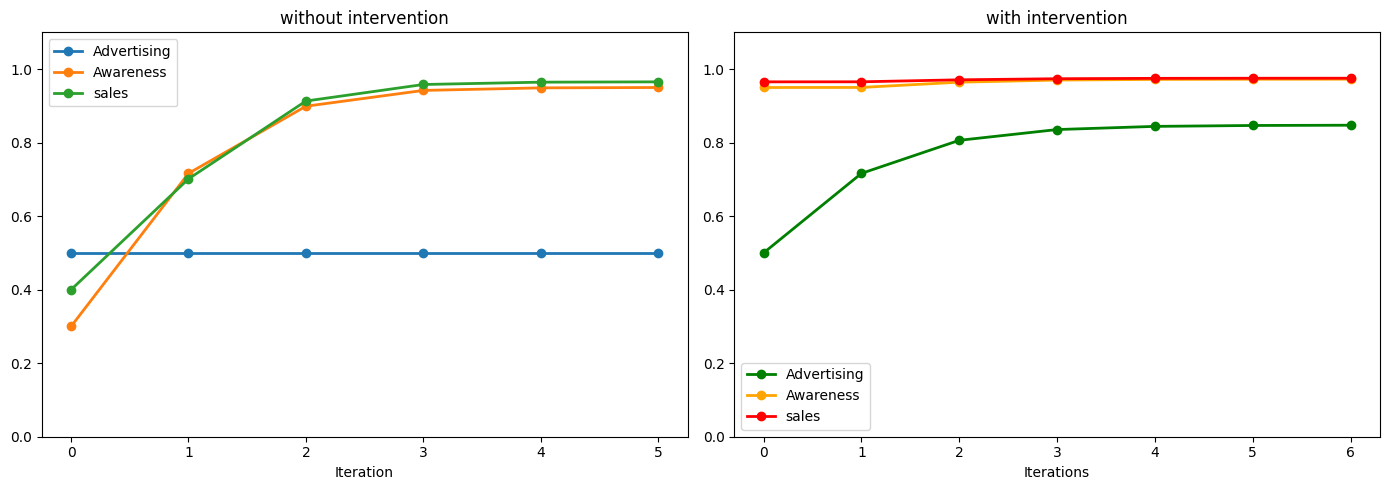

final value :
Advertising    0.500000
Awareness      0.949940
sales          0.965311
Name: 5, dtype: float64

final value with intervention :
Advertising    0.847340
Awareness      0.972546
sales          0.975207
Name: 6, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

baseline.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_xlabel("Iteration")
axes[0].set_title("without intervention")
axes[0].set_ylim(0, 1.1) 

intervention_result.plot(ax=axes[1], marker='o', linewidth=2, color=['green', 'orange', 'red'])
axes[1].set_xlabel("Iterations")
axes[1].set_title("with intervention")
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

print("final value :")
print(baseline.iloc[-1])
print("\nfinal value with intervention :")
print(intervention_result.iloc[-1])